In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.download import download_and_extract_data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from src.download import download_and_extract_data

### Глобальные переменные

In [4]:
dataset_path = Path("./data/Dunnhumby")
files_folder_path = Path("./data/files")

In [5]:
departments_to_keep = [
    'PRODUCE', 'GROCERY', 'MEAT', 'MEAT-PCKGD', 'MEAT-WHSE', 'PORK', 
    'DELI', 'DAIRY DELI', 'SEAFOOD', 'SEAFOOD-PCKGD', 'PASTRY', 
    'GRO BAKERY', 'FROZEN GROCERY', 'SALAD BAR', 'PROD-WHS SALES',
    'DRUG GM', 'HBC', 'NUTRITION', 'SPIRITS', 'DELI/SNACK BAR'
]

In [6]:
global_populatity_coef = 300
penetration_rate_coef = 30
user_frequency_coef = 5
interval_threshold_coef = 60
cv_threshhold_coef = 1.1

outflow_interval_threshold_coef = 3.0

In [190]:
# Коэффициенты перевода в базовые единицы (Граммы, Миллилитры, Штуки)
MULTIPLIERS = {
    'OZ': 28.35, 'OZS': 28.35, 'OUNCE': 28.35, 'LB': 453.59, 'LBS': 453.59,
    'GAL': 3785.41, 'GALLON': 3785.41, 'QT': 946.35, 'QUART': 946.35,
    'PT': 473.18, 'PINT': 473.18, 'LTR': 1000, 'LITER': 1000, 'ML': 1,
    'CT': 1, 'COUNT': 1, 'PK': 1, 'PACK': 1, 'DZ': 12, 'DOZEN': 12, 'DOZ': 12,
    'SQ FT': 1, 'SQFT': 1, 'ROLL': 1, 'RL': 1
}

# К какому физическому типу относится единица
UNIT_CATEGORIES = {
    'OZ': 'WEIGHT', 'OZS': 'WEIGHT', 'OUNCE': 'WEIGHT', 'LB': 'WEIGHT', 'LBS': 'WEIGHT',
    'GAL': 'VOLUME', 'GALLON': 'VOLUME', 'QT': 'VOLUME', 'QUART': 'VOLUME',
    'PT': 'VOLUME', 'PINT': 'VOLUME', 'LTR': 'VOLUME', 'LITER': 'VOLUME', 'ML': 'VOLUME',
    'CT': 'COUNT', 'COUNT': 'COUNT', 'PK': 'COUNT', 'PACK': 'COUNT', 'DZ': 'COUNT', 'DOZEN': 'COUNT', 'DOZ': 'COUNT',
    'SQ FT': 'COUNT', 'SQFT': 'COUNT', 'ROLL': 'COUNT', 'RL': 'COUNT' # Рулоны и площадь считаем как штуки для упрощения
}

In [235]:
MANUAL_OVERRIDES = {
    '120LD/211Z': (211.0 * 28.35, 'WEIGHT'),
    '100Z/24USE': (100.0 * 28.35, 'WEIGHT'),
    '51CT8KG51': (51.0, 'COUNT'),
    '1 KIT(3)': (1.0, 'COUNT'),
    '3/4X1000IN': (1.0, 'COUNT')
}

### Загрузка и просмотр данных

In [7]:
download_and_extract_data(dataset_path)

Все необходимые файлы уже на месте. Загрузка пропущена.


In [8]:
product_df = pd.read_csv(dataset_path / "product.csv")
transaction_data_df = pd.read_csv(dataset_path / "transaction_data.csv")

In [9]:
product_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   PRODUCT_ID            92353 non-null  int64
 1   MANUFACTURER          92353 non-null  int64
 2   DEPARTMENT            92353 non-null  str  
 3   BRAND                 92353 non-null  str  
 4   COMMODITY_DESC        92353 non-null  str  
 5   SUB_COMMODITY_DESC    92353 non-null  str  
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  str  
dtypes: int64(2), str(5)
memory usage: 4.9 MB


In [10]:
product_df.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [11]:
transaction_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [12]:
transaction_data_df["TRANS_TIME"].agg(["min", "max", "mean"])

min        0.000000
max     2359.000000
mean    1561.586139
Name: TRANS_TIME, dtype: float64

### Фильтрация данных

In [13]:
joined_df = transaction_data_df.merge(product_df, left_on="PRODUCT_ID", right_on="PRODUCT_ID")

In [14]:
raw_data = joined_df[
    [
        "household_key", "DAY", 
        "QUANTITY", "DEPARTMENT", 
        "BRAND", "COMMODITY_DESC", 
        "SUB_COMMODITY_DESC", "CURR_SIZE_OF_PRODUCT"
    ]
]
raw_data.shape

(2595732, 8)

In [15]:
raw_data = raw_data[raw_data["QUANTITY"] > 0]
raw_data.shape

(2581266, 8)

In [16]:
raw_data = raw_data[raw_data["DEPARTMENT"].isin(departments_to_keep)]
raw_data.shape

(2535094, 8)

In [17]:
raw_data["FULL CATEGORY"] = raw_data.COMMODITY_DESC + " || " + raw_data.SUB_COMMODITY_DESC

In [18]:
products_data = raw_data["FULL CATEGORY"]

In [19]:
products_data

0                  POTATOES || POTATOES RUSSET (BULK&BAG)
1                       ONIONS || ONIONS SWEET (BULK&BAG)
2                       VEGETABLES - ALL OTHERS || CELERY
3                               TROPICAL FRUIT || BANANAS
4          ORGANICS FRUIT & VEGETABLES || ORGANIC CARROTS
                                ...                      
2595727           MARGARINES || MARGARINE: TUBS AND BOWLS
2595728                 BEERS/ALES || BEERALEMALT LIQUORS
2595729                 BEERS/ALES || BEERALEMALT LIQUORS
2595730                 BEERS/ALES || BEERALEMALT LIQUORS
2595731                  MISC WINE || BEERALEMALT LIQUORS
Name: FULL CATEGORY, Length: 2535094, dtype: str

In [20]:
with open(files_folder_path / "sub_commodity.json", mode="w") as fout:
    json.dump(list(products_data.unique()), fout, indent=3)

In [21]:
with open(files_folder_path / "category_mapping.json", mode="r") as fin:
    category_mapping = json.load(fin)

In [22]:
new_category_list = list(set(category_mapping.values()))

In [23]:
with open(files_folder_path / "category_mapping.json", mode="w") as fout:
    json.dump(category_mapping, fout, indent=3)

In [24]:
raw_data["TOTAL CATEGORY"] = raw_data["FULL CATEGORY"].map(lambda cat: category_mapping[cat])

In [25]:
raw_data_without_ignore = raw_data[raw_data["TOTAL CATEGORY"] != "IGNORE"]
raw_data_without_ignore.shape

(2335633, 10)

In [26]:
raw_data_with_categories = raw_data_without_ignore[
    [
        "household_key", "DAY", 
        "QUANTITY", "CURR_SIZE_OF_PRODUCT",
        "TOTAL CATEGORY"
    ]
]
raw_data_with_categories.shape

(2335633, 5)

In [27]:
raw_data_with_categories["TOTAL CATEGORY"].unique().shape

(899,)

### Эвристика фильтрации 1 (Global popularity)

pandas.Series

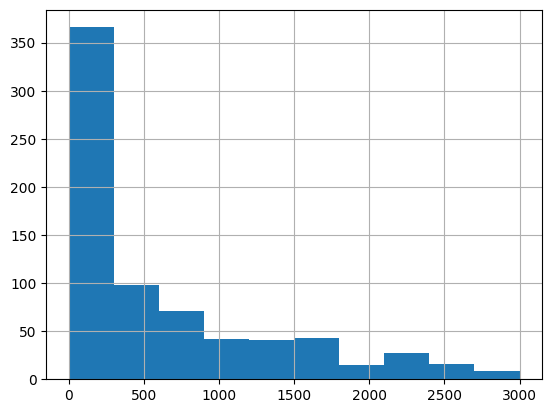

In [28]:
categories_transactions_count = raw_data_with_categories[["TOTAL CATEGORY", "household_key", "DAY"]].drop_duplicates()[["TOTAL CATEGORY", "DAY"]].groupby(by="TOTAL CATEGORY")["DAY"].count()
categories_transactions_count.name = "TRANSACTIONS COUNT"

categories_transactions_count.hist(bins=np.linspace(0, global_populatity_coef * 10, 11))
categories_transactions_count.__class__

In [29]:
merged1 = raw_data_with_categories.merge(categories_transactions_count, left_on="TOTAL CATEGORY", right_index=True)
after_first_filter = raw_data_with_categories[merged1["TRANSACTIONS COUNT"] > global_populatity_coef]
after_first_filter.shape, after_first_filter["TOTAL CATEGORY"].unique().shape

((2300458, 5), (532,))

### Эвристика фильтрации 2 (Penetration rate)

pandas.Series

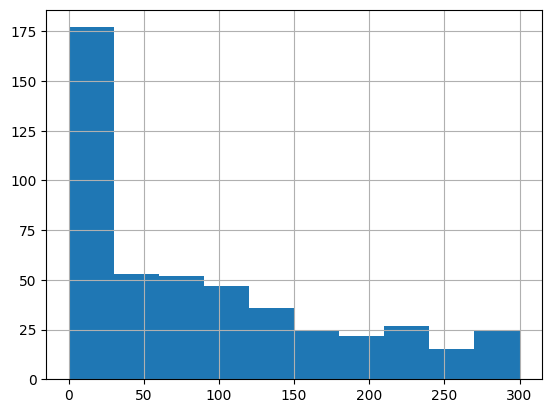

In [30]:
categories_households_count = raw_data_with_categories[["TOTAL CATEGORY", "household_key"]].drop_duplicates().groupby("TOTAL CATEGORY")["household_key"].count()
categories_households_count.name = "HOUSEHOLDS COUNT"

categories_households_count.hist(bins=np.linspace(0, penetration_rate_coef * 10, 11))
categories_households_count.__class__

In [31]:
merged2 = after_first_filter.merge(categories_households_count, left_on="TOTAL CATEGORY", right_index=True)
after_second_filter = after_first_filter[merged2["HOUSEHOLDS COUNT"] > penetration_rate_coef]
after_second_filter.shape, after_second_filter["TOTAL CATEGORY"].unique().shape

((2300458, 5), (532,))

### Эвристика фильтрации 3 (User frequency)

pandas.Series

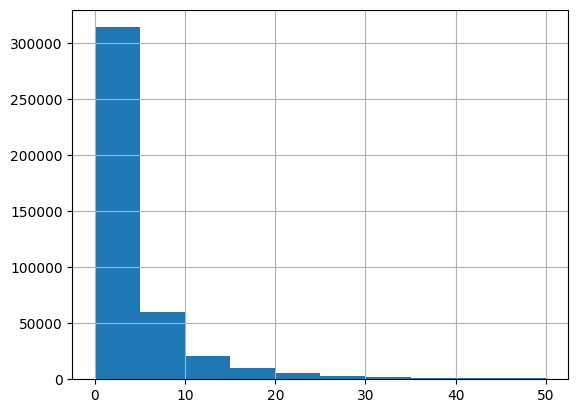

In [32]:
categoriesHouseholds_transactions_count = raw_data_with_categories[["TOTAL CATEGORY", "household_key", "DAY"]].drop_duplicates().groupby(by=["household_key", "TOTAL CATEGORY"])["DAY"].count()
categoriesHouseholds_transactions_count.name = "TRANSACTIONS COUNT"

categoriesHouseholds_transactions_count.hist(bins=np.linspace(0, user_frequency_coef * 10, 11))
categoriesHouseholds_transactions_count.__class__

In [33]:
merged3 = after_second_filter.merge(categoriesHouseholds_transactions_count, left_on=["household_key", "TOTAL CATEGORY"], right_index=True)
after_third_filter = after_second_filter[merged3["TRANSACTIONS COUNT"] > user_frequency_coef]
after_third_filter.shape, after_third_filter["TOTAL CATEGORY"].unique().shape

((1581662, 5), (532,))

### Эвристика фильтрации 4 (Interval threshold)

pandas.Series

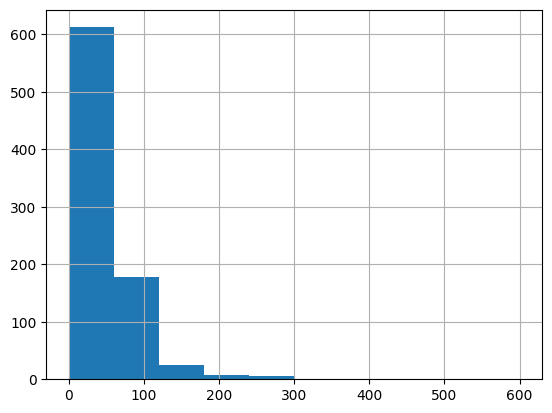

In [34]:
# 1. Сортируем по юзеру, ЗАТЕМ ПО КАТЕГОРИИ, затем по дню. 
# Это важно, чтобы покупки одной категории выстроились по порядку.
sorted_buf_data = raw_data_with_categories[["TOTAL CATEGORY", "household_key", "DAY"]].drop_duplicates().sort_values(by=["household_key", "TOTAL CATEGORY", "DAY"])

# 2. Группируем по ЮЗЕРУ И КАТЕГОРИИ одновременно!
sorted_buf_data["interval"] = sorted_buf_data.groupby(["household_key", "TOTAL CATEGORY"])["DAY"].diff()

# 3. Удаляем NA (первые покупки в каждой связке юзер-категория)
result = sorted_buf_data.dropna(subset=["interval"])

# 4. Считаем медиану
median_intervals = result.groupby("TOTAL CATEGORY")["interval"].median()
median_intervals.name = "MEDIAN INTERVAL"

# 5. Строим гистограмму
median_intervals.hist(bins=np.linspace(0, interval_threshold_coef * 10, 11))
median_intervals.__class__

In [35]:
merged4 = after_third_filter.merge(median_intervals, left_on="TOTAL CATEGORY", right_index=True)
after_fourth_filter = after_third_filter[merged4["MEDIAN INTERVAL"] <= interval_threshold_coef]
after_fourth_filter.shape, after_fourth_filter["TOTAL CATEGORY"].unique().shape

((1549168, 5), (434,))

### Эвристика фильтрации 5 (Variational coeficent)

pandas.Series

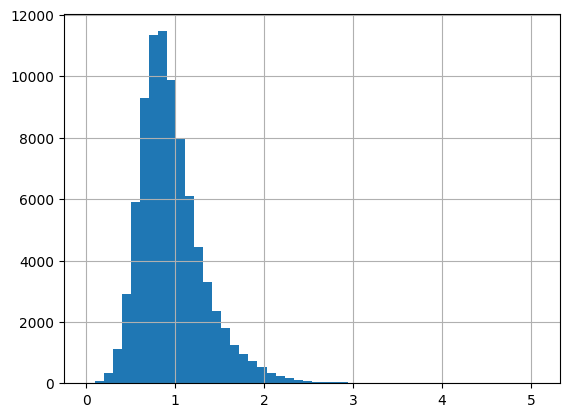

In [36]:
# 1. Сортируем по юзеру, ЗАТЕМ ПО КАТЕГОРИИ, затем по дню. 
# Это важно, чтобы покупки одной категории выстроились по порядку.
sorted_buf_data = after_fourth_filter[["TOTAL CATEGORY", "household_key", "DAY"]].drop_duplicates().sort_values(by=["household_key", "TOTAL CATEGORY", "DAY"])

# 2. Группируем по ЮЗЕРУ И КАТЕГОРИИ одновременно!
sorted_buf_data["interval"] = sorted_buf_data.groupby(["household_key", "TOTAL CATEGORY"])["DAY"].diff()

# 3. Удаляем NA (первые покупки в каждой связке юзер-категория)
result = sorted_buf_data.dropna(subset=["interval"])[["TOTAL CATEGORY", "household_key", "interval"]]

stats = result.groupby(["TOTAL CATEGORY", "household_key"])["interval"].agg(["mean", "std"])

cv_stats = stats["std"] / stats["mean"]
cv_stats.name = "cv_stats"

cv_stats.hist(bins=50)
cv_stats.__class__

In [37]:
filtered_cv_stats = cv_stats[cv_stats <= cv_threshhold_coef]
after_fifth_filter = after_fourth_filter.merge(filtered_cv_stats, left_on=["TOTAL CATEGORY", "household_key"], right_index=True)[["TOTAL CATEGORY", "household_key", "DAY", "QUANTITY", "CURR_SIZE_OF_PRODUCT"]]
after_fifth_filter.shape, after_fifth_filter["TOTAL CATEGORY"].unique().shape

((1119440, 5), (434,))

### Парсинг единиц измерений

In [ ]:
import re
import pandas as pd

In [183]:
patterns_left = 80

In [184]:
unique_sizes = raw_data_with_categories['CURR_SIZE_OF_PRODUCT'].fillna('MISSING')
pd.DataFrame({"CURR_SIZE_OF_PRODUCT": unique_sizes}).to_csv("./data/CURR_SIZE_OF_PRODUCT.csv")

In [206]:
base_num_pat = r"(?:\.\d+|\d+\.?\d*)"
frac_num_pat = rf"(?:{base_num_pat}\s?\/\s?{base_num_pat}|{base_num_pat})"
usa_frac_num_pat = rf"(?:{base_num_pat}(?:\s|\s?\-\s?){frac_num_pat})"
pattern = rf'(?:{usa_frac_num_pat}|{frac_num_pat})'

cleaning_pattern = r"^(N\s+|L\s+|L(?=\d)|B\s+|\*\s*|AB\s+|ALL\s*|R\s+|RR\s*|P\s+|P(?=\d)|@\s+|\-\s+|\A D\s+|EX\s*|BD\s+|:\s+|BCD\s+|CB \-\s+|EACH\s+|CR\s+|A D\s+|D\s+|KIOSK\s*|\+\s+|D\s+|Q\s+|CR\s+|A B D\s+|DISC\s+|ABD\s+|ABCD\s+|T\s+|SNGL\s+|ABCD\s+|\(C\)\s+|\)\s+|FN|\(\d+\)\s*|BIN\s*|CHILD\s*|SFT\s*|MN\s*|SOFT\s*|\.(?!\d))"

In [207]:
def get_pattern(text):
    if not isinstance(text, str): return "MISSING"
    text = text.upper().strip()
    
    text = re.sub(cleaning_pattern, "", text)
    # Объединенный паттерн:
    # \d+[\s-/]\d+  -- дроби вида 1/2, 1-1/2, 1 1/2
    # \d*\.?\d+     -- числа 10, 10.5, .5
    text = re.sub(pattern, ' $ ', text)
    
    text = re.sub(r"\/", " / ", text)

    # Схлопываем пробелы и чистим края
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 2. Создаем таблицу паттернов
patterns = pd.Series([get_pattern(s) for s in unique_sizes])
pattern_counts = patterns.value_counts()

print(f"Всего уникальных паттернов: {len(pattern_counts)}")
print("\nТоп-40 паттернов по частоте появления в справочнике:")
print(pattern_counts.iloc[patterns_left:patterns_left + 40])

# 3. Для анализа: выведем примеры оригинальных строк для самых частых паттернов
examples = pd.DataFrame({'original': unique_sizes})
examples['pattern'] = examples['original'].apply(get_pattern)

print("\nПримеры оригинальных строк для популярных паттернов:")
for pat in pattern_counts.iloc[patterns_left:patterns_left + 40].index:
    ex = examples[examples['pattern'] == pat]['original'].iloc[0]
    print(f"Паттерн [{pat}] -> Пример: '{ex}'")

Всего уникальных паттернов: 248

Топ-40 паттернов по частоте появления в справочнике:
$ OZ CANS       87
$ ROLL          86
LITER           86
$ CT / $ O      86
$ IN / $ OZ     80
$ CT / QT       74
$ DZN           74
HALF GAL        71
CTN             70
$ LTR*          69
$ USES          66
$ CT $ INCH     63
$ PK FM         57
PK / $ O        55
$ OZ( $ )       55
$ CT / QUART    51
$ QT / $ LB     49
$ IN            49
$ Z / $ QT      47
$ QUART         47
$ OZ SNGL       46
$ Z / $ CT      46
$ OZ( $ SL)     45
$ LB.           45
GALLON          43
$ OZ BAG        42
$ BAR / $ OZ    41
PK / $ OZ       40
$ PK CUBE       40
$ OZ POUCH      40
$ OZ / $ QT     37
$ LB BOX        35
$ OZ BOX        35
$ GAL / $ CT    34
$ PK / $        32
$ OZ $ PK       30
$ -LB BAG       30
QUART           30
$ PK / $ GAL    29
$ PK BTL        29
Name: count, dtype: int64


KeyboardInterrupt: 

In [231]:
def text_to_float(num_str):
    # Если из-за групп в регулярке пришел кортеж, берем самую полную совпавшую строку (индекс 0)
    if isinstance(num_str, tuple):
        num_str = num_str[0]
        
    num_str = num_str.strip()
    num_str = re.sub(r'\s*/\s*', '/', num_str)
    
    # Сценарий 1: Дроби (есть слеш)
    if '/' in num_str:
        num_str = num_str.replace('-', ' ')
        if ' ' in num_str:
            parts = num_str.split(' ')
            whole = parts[0]
            frac = parts[-1]
            return float(whole) + text_to_float(frac)
        else:
            parts = num_str.split('/')
            return float(parts[0]) / float(parts[1])
            
    # Сценарий 2: Диапазоны (есть дефис, но нет слеша)
    if '-' in num_str:
        parts = num_str.split('-')
        # Берем среднее значение диапазона
        return (float(parts[0].strip()) + float(parts[1].strip())) / 2.0
        
    # Сценарий 3: Два числа через пробел без слеша (ошибка парсинга)
    if ' ' in num_str:
        # Просто берем первое число, чтобы не падать с ошибкой
        return float(num_str.split(' ')[0])
        
    # Сценарий 4: Обычное число
    return float(num_str)

In [236]:
def extract_normalized_volume(raw_text: str, strict_warnings: bool = False) -> tuple[float, str, list[str]]:
    # 0. Заглушка для пустых значений
    if not isinstance(raw_text, str) or raw_text.strip() == '':
        return 1.0, 'COUNT', [] # По умолчанию 1 штука

    # 0. Проверка на захардкоженный случай ---
    clean_raw = raw_text.strip().upper()
    if clean_raw in MANUAL_OVERRIDES:
        return *MANUAL_OVERRIDES[clean_raw], []

    # 1. Сначала применяешь свой cleaning_pattern (чтобы убить мусор вроде (600))
    text = raw_text.strip()
    text = re.sub(cleaning_pattern, "", raw_text)
    text = text.upper()
    
    # 2. Ищем все числа (используя твой pattern для дробей)
    # re.findall вернет список совпадений. Так как в твоем pattern есть группы (), 
    # findall может вернуть кортежи. Тебе нужно вытащить именно саму строку с числом.
    raw_numbers = re.findall(pattern, text)
    try:
        numbers = [text_to_float(raw_number) for raw_number in raw_numbers]
    except:
        print("Ошибка при парсинге единиц измерения:")
        print(raw_numbers, raw_text)
    
    # 3. Ищем все известные единицы измерения из ключей MULTIPLIERS
    # Регулярка вида r'\b(OZ|LB|GAL|...)\b'
    text_for_units = re.sub(pattern, ' ', text)
    
    unit_pattern = r'\b(' + '|'.join(MULTIPLIERS.keys()) + r')\b'
    found_units = re.findall(unit_pattern, text_for_units)
    
    # 4. ЛОГИКА РАСЧЕТА (самое главное)
    # Получаем длины массивов
    n_count = len(numbers)
    u_count = len(found_units)

    # -----------------------------------------
    # БЛОК 0: Warnings
    # -----------------------------------------
    warnings = []
    if u_count == 0 and n_count == 2:
        warnings.append(f"WARNING: 2 числа и 0 единиц измерения при парсинге. Возможно наличие мусора. Строка: {raw_text}")
    if n_count > 2:
        warnings.append(f"WARNING: больше 2-х чисел при парсинге. Возможно наличие мусора. Строка: {raw_text}")
    if strict_warnings:
        if n_count == 2:
            warnings.append(f"STRICT WARNING: 2 числа при парсинге. Возможно наличие мусора. Строка: {raw_text}")
        if u_count == 2:
            warnings.append(f"STRICT WARNING: 2 единицы измерения при парсинге. Возможна ошибка в вычислениях. Строка: {raw_text}")

    # -----------------------------------------
    # БЛОК 1: Если чисел вообще нет
    # -----------------------------------------
    if n_count == 0:
        if u_count == 0:
            # Кейс 0x0
            return 1.0, 'COUNT', warnings
        else:
            # Кейсы 0x1 и 0x2
            target_unit = found_units[-1] # Берем последнюю единицу
            return 1.0 * MULTIPLIERS[target_unit], UNIT_CATEGORIES[target_unit], warnings

    # -----------------------------------------
    # БЛОК 2: Если единиц измерения нет (считаем в штуках)
    # -----------------------------------------
    if u_count == 0:
        if n_count == 1:
            # Кейс 1x0
            return float(numbers[0]), 'COUNT', warnings
        else:
            # Кейс 2x0 (и более)
            if numbers[0] < 100:
                return float(numbers[0] * numbers[-1]), 'COUNT', warnings
            else:
                return float(numbers[-1]), 'COUNT', warnings

    # -----------------------------------------
    # БЛОК 3: Есть и числа, и единицы измерения (Самый частый сценарий)
    # -----------------------------------------
    target_unit = found_units[-1] # Главная физическая величина всегда в конце
    multiplier = MULTIPLIERS[target_unit]
    category = UNIT_CATEGORIES[target_unit]

    if n_count == 1:
        # Кейсы 1x1 и 1x2
        return float(numbers[0] * multiplier), category, warnings
    else:
        # Кейсы 2x1 и 2x2 (Мультипаки)
        # numbers[-1] - это размер одной единицы товара
        # numbers[0] - это количество товаров в упаковке (если это не системный мусор)
        
        if numbers[0] < 100:
            total_value = numbers[0] * numbers[-1] * multiplier
        else:
            # Первое число слишком большое, игнорируем его как мусорный ID
            total_value = numbers[-1] * multiplier
            
        return float(total_value), category, warnings

In [237]:
for s in unique_sizes:
    _, _, warnings = extract_normalized_volume(s)
    if warnings:
        print(warnings)

### Определение оттока клиентов

pandas.Series

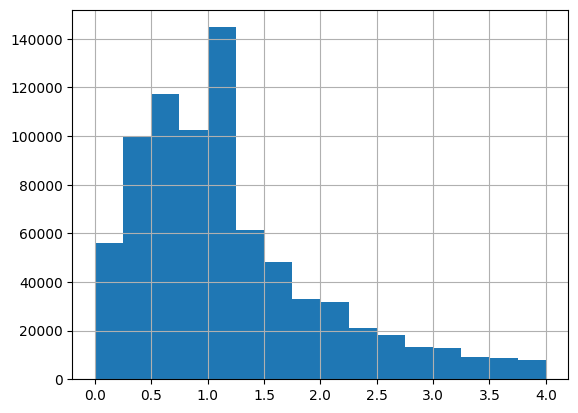

In [90]:
# 1. Сортируем по юзеру, ЗАТЕМ ПО КАТЕГОРИИ, затем по дню. 
# Это важно, чтобы покупки одной категории выстроились по порядку.
sorted_buf_data = after_fifth_filter[["TOTAL CATEGORY", "household_key", "DAY"]].drop_duplicates().sort_values(by=["household_key", "TOTAL CATEGORY", "DAY"])

# 2. Группируем по ЮЗЕРУ И КАТЕГОРИИ одновременно!
sorted_buf_data["interval"] = sorted_buf_data.groupby(["household_key", "TOTAL CATEGORY"])["DAY"].diff()

# 3. Удаляем NA (первые покупки в каждой связке юзер-категория)
result = sorted_buf_data.dropna(subset=["interval"])

# 4. Считаем медиану
median_intervals = result.groupby(["TOTAL CATEGORY", "household_key"])["interval"].median()
median_intervals.name = "MEDIAN INTERVAL"

with_intervals_diff = sorted_buf_data.merge(median_intervals, left_on=["TOTAL CATEGORY", "household_key"], right_index=True)
with_intervals_diff["intervals diff"] = with_intervals_diff["interval"] / with_intervals_diff["MEDIAN INTERVAL"]
with_intervals_diff.drop(["interval", "MEDIAN INTERVAL"], axis=1, inplace=True)


# 5. Строим гистограмму
with_intervals_diff["intervals diff"].hist(bins=np.linspace(0, 4, 17))
with_intervals_diff["intervals diff"].__class__

In [95]:
merged6 = after_fifth_filter.merge(with_intervals_diff, on=["TOTAL CATEGORY", "household_key", "DAY"])
merged6["is group begin"] = merged6["intervals diff"].case_when([(lambda series: series < outflow_interval_threshold_coef, 0), (lambda series: pd.Series([True] * series.size), 1)])
merged6

,TOTAL CATEGORY,household_key,DAY,QUANTITY,CURR_SIZE_OF_PRODUCT,intervals diff,is group begin
0,COOKIES,2375,1,1,18 OZ,NaN,1.0
1,SNACK CRACKERS,1364,1,1,9.5 OZ,NaN,1.0
2,RAMEN,1130,1,2,3 OZ,NaN,1.0
3,RAMEN,1130,1,2,3 OZ,NaN,1.0
4,RAMEN,1130,1,2,3 OZ,NaN,1.0
...,...,...,...,...,...,...,...
1119435,FROZEN PIZZA,1598,711,1,22.5 OZ,1.000000,0.0
1119436,SPORTS DRINK,1598,711,1,32 OZ,1.240310,0.0
1119437,PEANUT BUTTER,1598,711,1,ALL 18 OZ,0.766667,0.0
1119438,MACARONI AND CHEESE,1598,711,1,7.25 OZ,0.382353,0.0
